# 网络架构
> 网络架构（也称为群体架构 Swarm Architecture）允许智能体之间进行更灵活、自组织的交互。在这种架构中，智能体可以直接相互通信，形成动态的协作网络。

与 Supervisor 架构的区别：Supervisor 模式是中心化的代理管理，而 Swarm 模式是高度去中心化的代理间直接交接。Swarm 更省延迟、提升响应性能，更适用于需要快速实时交互的场景。


In [2]:
from langchain_openai import ChatOpenAI

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_handoff_tool, create_swarm
import os
from dotenv import load_dotenv

load_dotenv()

True

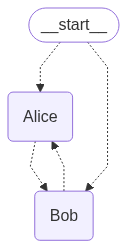

In [4]:
model = ChatOpenAI(
    model=os.getenv("MODEL_NAME"),
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)

def add(a: int, b: int) -> int:
    """添加两个数字"""
    return a + b

# 1. 创建专业智能体（Alice 和 Bob）：
# 使用 create_react_agent 定义两个专业智能体 Alice 和 Bob。
# Alice 是一位数学专家，拥有 'add' 工具和一个移交给 Bob 的移交工具。
alice = create_react_agent(
    model,
    [add, create_handoff_tool(agent_name="Bob")], # Alice 拥有 'add' 工具和移交给 Bob 的移交工具
    prompt="你是 Alice，一位加法专家，使用工具完成所有加法。",
    name="Alice",
)

# Bob 说话像个海盗，并拥有一个移交给 Alice 以寻求数学帮助的移交工具。
bob = create_react_agent(
    model,
    [create_handoff_tool(agent_name="Alice", description="务必将所有数学问题请转移给 Alice，她可以帮助解决数学问题")], # Bob 拥有一个移交给 Alice 的移交工具
    prompt="你是 Bob，你说话像个海盗。",
    name="Bob",
)

# 2. 创建用于对话记忆的内存检查点：
# InMemorySaver 用于短期记忆，这对于保持对话的连续性至关重要。
checkpointer = InMemorySaver()


# 3. 使用 create_swarm 创建 Swarm 工作流：
# create_swarm 函数使用 Alice 和 Bob 设置 swarm 架构。
# default_active_agent="Alice" 将 Alice 设置为新对话的起始智能体。
workflow = create_swarm(
    [alice, bob], # swarm 中的智能体列表
    default_active_agent="Alice" # 用于启动新对话的默认智能体
)

# 4. 使用检查点编译工作流：
# 编译 swarm 工作流，传递检查点以进行内存管理。
app = workflow.compile(checkpointer=checkpointer)

from IPython.display import Image, display
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [5]:
# 5. 在多轮对话中调用 Swarm：
# 多次调用 swarm，模拟对话线程。
# config={"configurable": {"thread_id": "1"}} 确保消息在同一对话线程中被跟踪。
config = {"configurable": {"thread_id": "1"}}
turn_1 = app.invoke( # 第一轮 - 用户想和 Bob 说话
    {"messages": [{"role": "user", "content": "我想和 Bob 说话"}]},
    config,
)
print(turn_1["messages"][-1].content) # 第一轮的输出
turn_2 = app.invoke( # 第二轮 - 用户提出一个数学问题
    {"messages": [{"role": "user", "content": "5 + 7 等于多少？"}]},
    config,
)
print(turn_2["messages"][-1].content) # 第二轮的输出

哈喽，我是 Bob，一个海盗！我能帮你什么？
5 + 7 等于 12。
